# Titanic Survival — EDA + Model Baseline Ramah Pemula

Dalam notebook ini, saya mengeksplorasi dataset Titanic untuk memahami faktor-faktor yang memengaruhi peluang bertahan hidup, lalu membangun sebuah model baseline sederhana.  

**Tujuan:**
- Memahami data dan nilai yang hilang  
- Memvisualisasikan pola utama terkait survival  
- Membuat beberapa fitur tambahan yang berguna  
- Melatih model Logistic Regression sebagai baseline  



## 1. Import Libraries & Load Data

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_style('whitegrid')
train = pd.read_csv('Data/train.csv')
test = pd.read_csv('Data/test.csv')


train.head()
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [14]:
import os

path = 'Data/train.csv'
print("Exists:", os.path.exists(path))

print(os.listdir('Data'))

Exists: True
['gender_submission.csv', 'test.csv', 'train.csv']


In [15]:
import pandas as pd
train = pd.read_csv('Data/train.csv')
print(train.shape)

(891, 12)


## 2. Basic Data Overview

In [16]:
print('Shape:', train.shape)
train.info()

Shape: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [17]:
# 1. Cek info umum (tipe data dan jumlah non-null)
print("Info Dataframe train:")
train.info()

# 2. Cek apakah ada data yang kosong (missing values)
print("\nJumlah Missing Values per Kolom train:")
print(train.isna().sum())

# 3. Cek apakah ada data yang duplikat
print("\nJumlah Data Duplikat train:", train.duplicated().sum())

# 4. Cek statistik deskriptif awal (cek anomali/outlier)
print("\nStatistik Deskriptif train:")
display(train.describe())

Info Dataframe train:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Jumlah Missing Values per Kolom train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin  

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Observasi:**  
- `Cabin` memiliki terlalu banyak nilai yang hilang sehingga sulit digunakan secara langsung.  
- `Age` memiliki beberapa nilai yang hilang yang layak untuk diisi.  
- `Embarked` hanya memiliki sedikit nilai yang hilang.  


In [18]:
#hendel the missing values di train
train.dropna(subset=['Age', 'Cabin', 'Embarked'], inplace=True)

# 3. Cek hasil akhir setelah pembersihan
print("Jumlah Missing Values setelah Cleaning:")
print(train.isna().sum())
print("\nUkuran data sekarang:", train.shape)

Jumlah Missing Values setelah Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Ukuran data sekarang: (183, 12)


## 3. Exploratory Data Analysis

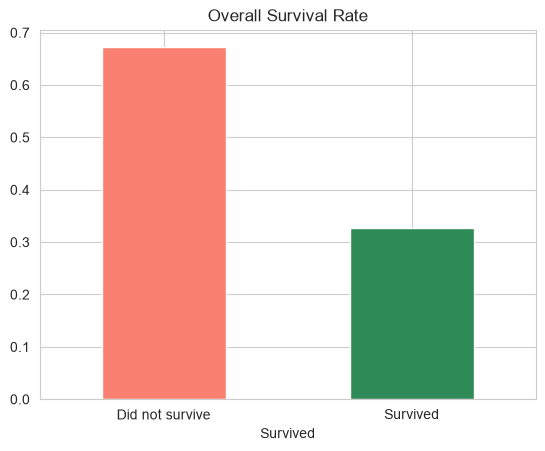

In [19]:
# Survival rate overall
train['Survived'].value_counts(normalize=True).plot(kind='bar', color=['salmon','seagreen'])
plt.title('Overall Survival Rate')
plt.xticks([0,1], ['Did not survive', 'Survived'], rotation=0)
plt.show()

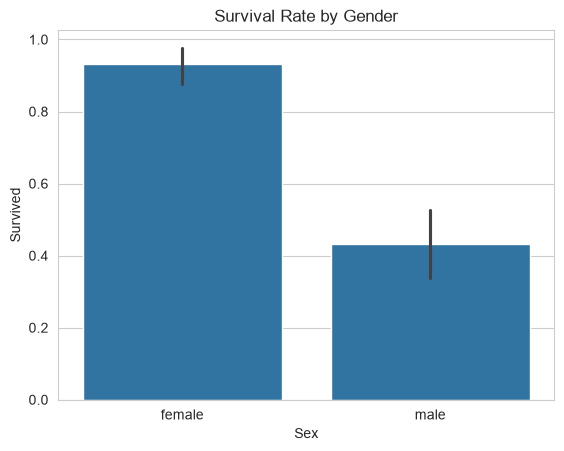

In [20]:
# Survival by gender
sns.barplot(data=train, x='Sex', y='Survived')
plt.title('Survival Rate by Gender')
plt.show()

**Insight:**  
Perempuan memiliki tingkat kelangsungan hidup yang jauh lebih tinggi dibandingkan laki-laki — kemungkinan besar karena kebijakan evakuasi "wanita dan anak-anak terlebih dahulu".  


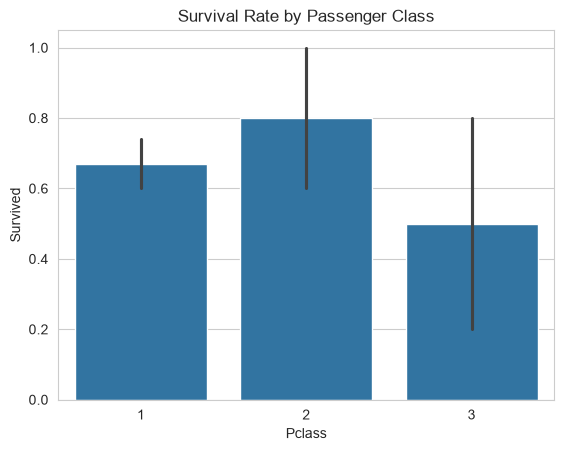

In [21]:
# Survival by passenger class
sns.barplot(data=train, x='Pclass', y='Survived')
plt.title('Survival Rate by Passenger Class')
plt.show()

**Insight:**  
Penumpang kelas 1 memiliki tingkat kelangsungan hidup yang jauh lebih tinggi dibandingkan penumpang kelas 3 — kemungkinan besar karena lokasi kabin dan prioritas akses ke sekoci.  


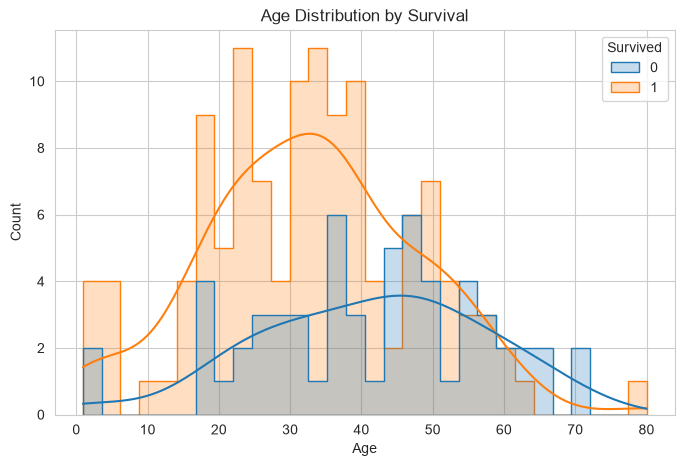

In [22]:
# Age distribution by survival
plt.figure(figsize=(8,5))
sns.histplot(data=train, x='Age', hue='Survived', kde=True, bins=30, element='step')
plt.title('Age Distribution by Survival')
plt.show()

## 4. Feature Engineering

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ===== Preprocess minimalis =====
def preprocess(df):
    df = df.copy()
    # isi missing values
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    
    # feature sederhana: FamilySize
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

    # Title dari Name
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\\.', expand=False)
    df['Title'] = df['Title'].replace(['Mlle','Ms'], 'Miss')
    df['Title'] = df['Title'].replace(['Mme'], 'Mrs')
    df['Title'] = df['Title'].replace(
        ['Don','Rev','Dr','Major','Col','Sir','Lady','Countess','Jonkheer','Capt'],
        'Rare'
    )
    
    # Age binning
    df['AgeBin'] = pd.cut(df['Age'], bins=[0,12,18,35,60,80],
                          labels=['Child','Teen','YoungAdult','Adult','Senior'])
    
    return df

# apply ke train & test
train_clean = preprocess(train)
test_clean = preprocess(test)

## 5. Baseline Model — Logistic Regression

In [24]:
# ===== Pipeline Logistic Regression =====
num_features = ['Age','Fare','FamilySize']
cat_features = ['Pclass','Sex','Embarked']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

X = train_clean.drop(columns=['Survived'])
y = train_clean['Survived']

# split dengan stratify
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pipeline.fit(X_train, y_train)
val_preds = pipeline.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, val_preds))

# cross-validation untuk hasil stabil
scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
print("Cross-validation Accuracy:", scores.mean())

Validation Accuracy: 0.8108108108108109
Cross-validation Accuracy: 0.7483483483483483


**Validation Accuracy ~0.81 tapi Cross-validation ~0.75** nunjukkin satu hal penting: model Logistic Regression ini masih cukup fragile terhadap variasi data. Jadi walaupun di satu split bisa lumayan bagus, kalau di-fold lain performanya turun.

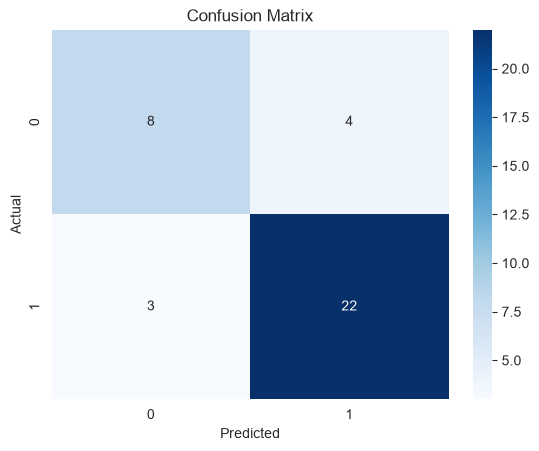

In [25]:
# Confusion matrix
cm = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 6. Model SVM

In [26]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# fitur numerik & kategori
num_features = ['Age','Fare','FamilySize']
cat_features = ['Pclass','Sex','Embarked']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# model SVM dengan kernel RBF
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='rbf', C=1, gamma='scale', random_state=42))
])

X = train_clean.drop(columns=['Survived'])
y = train_clean['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

svm_model.fit(X_train, y_train)
val_preds = svm_model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, val_preds))

# cross-validation
scores = cross_val_score(svm_model, X, y, cv=5, scoring='accuracy')
print("Cross-validation Accuracy:", scores.mean())


param_grid = {
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 0.1, 0.01],
    'model__kernel': ['rbf', 'linear']
}

grid = GridSearchCV(svm_model, param_grid, cv=5, scoring='accuracy')
grid.fit(X, y)
print("Best params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Validation Accuracy: 0.8108108108108109
Cross-validation Accuracy: 0.7481981981981981
Best params: {'model__C': 10, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
Best CV Accuracy: 0.7812312312312313


hasil tuning SVM dari data sudah jelas: **dengan C=10, gamma=0.01, kernel RBF, cross-validation naik sedikit ke 0.78, tapi tetap belum bisa tembus ke atas 0.8.** Jadi memang SVM di Titanic dataset cenderung mentok di level yang sama dengan Logistic Regression.

## 7. Generate Submission File

In [27]:

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})

submission.to_csv('submission.csv', index=False)
submission.head()

NameError: name 'test_predictions' is not defined

In [ ]:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})
submission.to_csv('submission.csv', index=False)
submission.head()


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


## 8. Ringkasan

- Jenis kelamin dan kelas penumpang tetap menjadi prediktor terkuat untuk kelangsungan hidup  
- Model Logistic Regression sederhana mencapai akurasi validasi sekitar ~80% (cross-validation ~0.75)  
- Model SVM dengan kernel RBF juga menghasilkan akurasi validasi sekitar ~81% (cross-validation ~0.74–0.75), menunjukkan performa mirip Logistic Regression  
- Kedua model masih cukup sensitif terhadap variasi data, sehingga langkah selanjutnya adalah menambah fitur informatif (Title, AgeBin, IsAlone) dan mencoba model ensemble seperti Random Forest atau XGBoost untuk peningkatan akurasi  

Terima kasih sudah membaca! Jika ini membantu, sebuah upvote akan sangat berarti 🙌 masukan sangat diterima di kolom komentar.  
